# Does Model Confidence Track Real Visibility in Disaster Satellite Imagery?

**A diagnostic study of "blind confidence" in cloud-occluded flood mapping**

This notebook tests whether flood-segmentation models stay falsely confident once optical
satellite imagery is degraded by cloud cover — the exact condition under which they are most
needed (monsoon-season flooding is highly correlated with heavy cloud cover). It extends a
confidence-vs-visibility diagnostic (GapAUC: mean confidence minus accuracy, integrated over a
degradation severity ladder) from synthetic image corruption in VLMs to a *real* Earth-observation
task, using the public **Sen1Floods11** benchmark (Bonafilia et al., CVPR-W 2020).

**⚠️ Read this before running.** This notebook auto-downloads ~14 GB of satellite imagery from a
public Google Cloud Storage bucket and trains 3 small U-Nets on a T4. Two things you should
verify on your own machine before trusting the results:
1. **Set `DRY_RUN = True` first** (see Config cell) and run the whole notebook once. This swaps
   in tiny synthetic data so every cell executes end-to-end in under a minute — it validates the
   *pipeline*, not the science. All DRY-RUN figures/tables are watermarked and suffixed
   `_DRYRUN` so they can never be mistaken for real results.
2. Only then set `DRY_RUN = False` and run for real. The dataset download step contacts Google
   Cloud Storage directly; if your runtime has no general internet access it will fail loudly
   with an explicit error rather than silently substituting fake data — see Section 5.

Sen1Floods11's `S2Hand` layer (hand-labeled Sentinel-2 chips) does **not** ship an official cloud
mask, so the degradation ladder here is a controlled *synthetic* cloud-occlusion overlay
(multi-octave noise, calibrated to a target coverage fraction) composited onto real chips,
evaluated against real hand-labeled flood/no-flood ground truth. This is weaker than a
naturally-occurring cloud mask but stronger than fully synthetic imagery, and it is the same
"controlled ladder" logic already used for the VLM version of this study — just swapped from
Gaussian blur to a physically-motivated cloud model.


## Section 1 — Setup

In [1]:
# --- Dependencies ---------------------------------------------------------
import subprocess, sys
def _pip(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for _pkg in ["rasterio", "segmentation-models-pytorch"]:
    try:
        __import__(_pkg.replace("-", "_"))
    except ImportError:
        _pip(_pkg)
print("Dependencies ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.9 MB/s eta 0:00:00
Dependencies ready.


In [2]:
# --- Imports, seeds, device, reproducibility -------------------------------
import os, json, random, warnings, time, zipfile, urllib.request, urllib.error
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.ndimage import zoom
from scipy import stats as sstats
import matplotlib
try:
    get_ipython()  # noqa: F821 -- defined by IPython/Colab; NameError means a plain script
    # In Jupyter/Colab: do NOT force a headless backend, or figures will save to disk
    # correctly but never actually appear in the notebook output.
except NameError:
    matplotlib.use("Agg")  # plain-script / CI context with no display
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def trapz(y, x):
    # numpy >=2.0 renamed trapz -> trapezoid; support both
    fn = getattr(np, "trapezoid", None) or np.trapz
    return fn(y, x)

print(f"torch {torch.__version__} | device: {DEVICE}"
      + (f" ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else " (NO GPU — this will be slow; use a T4 runtime)"))
print(f"numpy {np.__version__} | pandas {pd.__version__}")

OUT_DIR = "outputs"
FIG_DIR = os.path.join(OUT_DIR, "figures")
TAB_DIR = os.path.join(OUT_DIR, "tables")
LOG_DIR = os.path.join(OUT_DIR, "logs")
DATA_DIR = "data"
for d in [OUT_DIR, FIG_DIR, TAB_DIR, LOG_DIR, DATA_DIR]:
    os.makedirs(d, exist_ok=True)
print("Output directories ready:", OUT_DIR)


torch 2.10.0+cu128 | device: cuda (Tesla T4)
numpy 2.0.2 | pandas 2.3.3
Output directories ready: outputs


In [3]:
# --- CONFIG — the only cell you should need to edit ------------------------
DRY_RUN = False          # <-- START HERE. True = synthetic smoke test (~1 min, no download).
                         #     Set False only after a DRY_RUN pass succeeds.
MAX_CHIPS = 320          # cap on real chips used. Section 5 now pools the official
                         # train+valid+test splits together (~few hundred chips combined)
                         # before doing our own random re-split -- 320 targets roughly
                         # 60+ val chips, which matters: with a Clopper-Pearson upper bound,
                         # certifying a <=10% missed-flood rate needs on the order of
                         # ~n>=30 zero-miss calibration chips (1 - 0.05^(1/n) <= 0.10); the
                         # old MAX_CHIPS=120 (-> ~24 val chips after the 60/20/20 split) made
                         # TARGET_MISS_RATE mathematically uncertifiable even in the best case.
IMG_SIZE = 256           # chips are resized 512->IMG_SIZE for T4 memory/time budget
EPOCHS = 20
BATCH_SIZE = 8
LR = 1e-3
SEVERITIES = [0.0, 0.15, 0.30, 0.45, 0.60, 0.75, 0.90]   # synthetic cloud-coverage ladder
TARGET_MISS_RATE = 0.10   # selective-prediction target: calibrated upper bound on missed-flood rate
ALPHA = 0.05              # CI / risk-control confidence level
N_PERM = 20000            # permutation-test resamples (was 2000; that made p=0.0005 a floor
                           # artifact of resample count, not a measured p-value)
N_BOOT = 2000

if DRY_RUN:
    print("=" * 70)
    print("  DRY RUN MODE — using tiny synthetic data. Figures/tables below are")
    print("  WATERMARKED '_DRYRUN' and MUST NOT be used as real results.")
    print("=" * 70)


## Section 2 — Problem Definition

**Setting.** A flood classifier $f$ outputs, per pixel $x$, a probability $p(x)\in[0,1]$ that the
pixel is water. Confidence is $c(x) = \max(p(x), 1-p(x))$, and image-level confidence
$\bar c = \mathbb{E}_x[c(x)]$ over valid (non-nodata) pixels. Let $s \in [0,1]$ denote synthetic
cloud-coverage severity applied to the optical channel, and $\mathrm{Acc}(s)$ the pixel accuracy
against real hand-labeled ground truth at severity $s$.

**Diagnostic metric — GapAUC.** Following the same construction used for the VLM degradation-ladder
study, define the confidence–accuracy gap $g(s) = \bar c(s) - \mathrm{Acc}(s)$ and

$$\mathrm{GapAUC} = \int_0^{s_{\max}} g(s)\, ds \;\approx\; \sum_i \tfrac{1}{2}(g(s_i)+g(s_{i+1}))(s_{i+1}-s_i)$$

estimated by the trapezoidal rule over the severity grid, with chip-clustered bootstrap CIs
(resampling whole chips, not pixels, to respect the actual unit of statistical independence).
GapAUC $\approx 0$ means confidence tracks real degradation ("knows what it can't see"); GapAUC
$\gg 0$ means the model stays confident well past the point of being informative ("blind
confidence").

**Falsifiable hypotheses.**
- **H1.** The optical-only model's GapAUC is significantly greater than zero and grows with
  cloud severity.
- **H2.** A SAR-only model (immune to optical cloud occlusion by construction) has GapAUC
  statistically indistinguishable from zero, and an SAR+optical fusion model has GapAUC
  significantly smaller than the optical-only model's.
- **H3.** A confidence threshold $\tau$ calibrated on held-out data to bound the missed-flood
  rate (false-negative rate on water pixels) at $\mathrm{TARGET\_MISS\_RATE}$ via a Clopper–Pearson
  upper confidence bound continues to hold that bound (within noise) at held-out test severities —
  i.e., the calibration transfers instead of silently failing under degradation.

Each hypothesis is checked against real computed numbers below, not assumed.


## Section 3 — Method

In [4]:
# --- Synthetic cloud-occlusion ladder ---------------------------------------
def synth_cloud_mask(h, w, target_coverage, seed=0, octaves=5):
    '''Multi-octave value-noise opacity field in [0,1] (1 = fully opaque cloud),
    calibrated so mean opacity ~= target_coverage.'''
    if target_coverage <= 0:
        return np.zeros((h, w), dtype=np.float32)
    if target_coverage >= 1:
        return np.ones((h, w), dtype=np.float32)
    rng = np.random.RandomState(seed)
    field = np.zeros((h, w), dtype=np.float32)
    amp, total_amp = 1.0, 0.0
    for o in range(octaves):
        gh = max(2, h // (2 ** (octaves - o)) + 2)
        gw = max(2, w // (2 ** (octaves - o)) + 2)
        small = rng.rand(gh, gw).astype(np.float32)
        layer = zoom(small, (h / small.shape[0], w / small.shape[1]), order=3)[:h, :w]
        field += amp * layer
        total_amp += amp
        amp *= 0.55
    field /= total_amp
    field = (field - field.min()) / (field.max() - field.min() + 1e-8)
    thresh = np.quantile(field, 1 - target_coverage)
    return (1.0 / (1.0 + np.exp(-(field - thresh) * 12))).astype(np.float32)

def apply_cloud(optical_bands01, cloud_opacity, cloud_reflectance=0.85):
    '''optical_bands01: (C,H,W) in [0,1]. Blend each band toward bright cloud reflectance.'''
    c = cloud_opacity[None, :, :]
    return optical_bands01 * (1 - c) + cloud_reflectance * c

print("Cloud-ladder functions defined. Example mean opacities:",
      [round(float(synth_cloud_mask(64,64,s,seed=1).mean()),3) for s in SEVERITIES])


Cloud-ladder functions defined. Example mean opacities: [0.0, 0.201, 0.323, 0.46, 0.589, 0.715, 0.845]


In [5]:
# --- Confidence / GapAUC / statistical-inference helpers --------------------
def confidence_from_logits(logits):
    p = torch.sigmoid(logits)
    return torch.maximum(p, 1 - p)

def gap_auc(severities, conf_minus_acc):
    return float(trapz(np.asarray(conf_minus_acc), np.asarray(severities)))

def chip_clustered_bootstrap_ci(per_chip_gap_series, severities, n_boot=N_BOOT, seed=SEED, alpha=ALPHA):
    '''per_chip_gap_series: array (n_chips, n_severities) of (confidence-accuracy) per chip
    per severity. Resamples whole chips, recomputes GapAUC each time.'''
    rng = np.random.RandomState(seed)
    per_chip_gap_series = np.asarray(per_chip_gap_series)
    n_chips = per_chip_gap_series.shape[0]
    point = gap_auc(severities, per_chip_gap_series.mean(axis=0))
    boots = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.randint(0, n_chips, n_chips)
        boots[b] = gap_auc(severities, per_chip_gap_series[idx].mean(axis=0))
    lo, hi = np.percentile(boots, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return point, float(lo), float(hi), boots

def permutation_test_gapauc(gaps_a_chips, gaps_b_chips, severities, n_perm=N_PERM, seed=SEED):
    '''Two-sided permutation test on the difference of GapAUC between two models,
    permuting chip labels (a vs b) jointly across severities.'''
    rng = np.random.RandomState(seed)
    a = np.asarray(gaps_a_chips)  # (n_chips, n_sev)
    b = np.asarray(gaps_b_chips)
    obs = gap_auc(severities, a.mean(0)) - gap_auc(severities, b.mean(0))
    pooled = np.concatenate([a, b], axis=0)
    n_a = a.shape[0]
    n = pooled.shape[0]
    count = 0
    for _ in range(n_perm):
        perm = rng.permutation(n)
        pa, pb = pooled[perm[:n_a]], pooled[perm[n_a:]]
        diff = gap_auc(severities, pa.mean(0)) - gap_auc(severities, pb.mean(0))
        if abs(diff) >= abs(obs):
            count += 1
    p_raw = (count + 1) / (n_perm + 1)
    return float(obs), float(p_raw)

print("Statistical helper functions defined.")


Statistical helper functions defined.


In [6]:
# --- Selective prediction: calibrated abstention on missed-flood rate -------
def clopper_pearson_upper(successes, n, alpha=ALPHA):
    '''Upper 1-alpha confidence bound on a Bernoulli rate given `successes` out of `n`.'''
    if n == 0:
        return 1.0
    if successes == n:
        return 1.0
    return float(sstats.beta.ppf(1 - alpha, successes + 1, n - successes))

def calibrate_abstention_threshold(chip_confidences, chip_miss_indicators, target_rate=TARGET_MISS_RATE, alpha=ALPHA):
    '''Search confidence thresholds tau; keep chips with confidence>=tau ('trusted'); pick the
    LOWEST tau (= highest coverage) whose Clopper-Pearson upper bound on missed-flood rate,
    among trusted chips, stays <= target_rate. Returns (tau, coverage, calib_upper_bound).'''
    chip_confidences = np.asarray(chip_confidences)
    chip_miss_indicators = np.asarray(chip_miss_indicators)  # 1 if that chip had a missed flood, else 0
    candidates = np.sort(np.unique(chip_confidences))
    best_tau, best_cov = None, -1.0
    for tau in candidates:
        trusted = chip_confidences >= tau
        n_trusted = int(trusted.sum())
        if n_trusted < 5:   # too few calibration chips to say anything
            continue
        misses = int(chip_miss_indicators[trusted].sum())
        ub = clopper_pearson_upper(misses, n_trusted, alpha)
        if ub <= target_rate:
            cov = n_trusted / len(chip_confidences)
            if cov > best_cov:
                best_tau, best_cov, best_ub = tau, cov, ub
    if best_tau is None:
        return None, 0.0, None
    return float(best_tau), float(best_cov), float(best_ub)

print("Selective-prediction calibration function defined.")


Selective-prediction calibration function defined.


## Section 4 — Baselines

Four models, all evaluated identically across the cloud-severity ladder:
1. **NDWI threshold** — classic remote-sensing water index, no training, no learned confidence.
2. **SAR-only U-Net** — sees only Sentinel-1 (VV, VH); cloud-invariant by construction, so it is
   the "ground-truth visibility" control: its accuracy *should not* move with optical cloud cover.
3. **Optical-only U-Net** — sees only Sentinel-2 RGB+NIR; this is the model under test for
   "blind confidence."
4. **SAR+optical fusion U-Net** — early fusion of both; tests whether cheap sensor fusion
   recovers the confidence–visibility gap.


In [7]:
# --- Model builder (small U-Net, ImageNet encoder with safe fallback) -------
import segmentation_models_pytorch as smp

def build_unet(in_channels):
    try:
        m = smp.Unet(encoder_name="resnet18", encoder_weights="imagenet",
                      in_channels=in_channels, classes=1)
    except Exception as e:
        print(f"  [warn] pretrained ImageNet weights unavailable ({type(e).__name__}); "
              f"falling back to random init (still valid, just slower to converge).")
        m = smp.Unet(encoder_name="resnet18", encoder_weights=None,
                      in_channels=in_channels, classes=1)
    return m.to(DEVICE)

def ndwi_predict(s2_01):
    '''s2_01: (13,H,W) in [0,1]. Returns (pred_water_mask, confidence_map) both (H,W).'''
    green, nir = s2_01[2], s2_01[7]
    ndwi = (green - nir) / (green + nir + 1e-6)
    pred = (ndwi > 0).astype(np.float32)
    conf = np.clip(np.abs(ndwi) * 3.0, 0, 1)  # map |NDWI| to a pseudo-confidence in [0,1]
    return pred, conf

print("Baseline builders defined: NDWI (rule-based), SAR-U-Net, Optical-U-Net, Fusion-U-Net.")


Baseline builders defined: NDWI (rule-based), SAR-U-Net, Optical-U-Net, Fusion-U-Net.


## Section 5 — Dataset (Sen1Floods11, hand-labeled subset)

Public dataset (Bonafilia et al., CVPR-W 2020), CC-BY license. Bucket layout verified against the
official repo README (`github.com/cloudtostreet/Sen1Floods11`) at the time this notebook was
written:

```
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/{EVENT}_{CHIP}_S1Hand.tif   (VV,VH ; float32 dB)
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S2Hand/{EVENT}_{CHIP}_S2Hand.tif   (13 bands ; uint16, TOA*10000, no QA mask)
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/{EVENT}_{CHIP}_LabelHand.tif (-1/0/1 ; int16)
gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_{train,valid,test}_data.csv
```

**Honesty note:** this download step was verified against the dataset's public documentation but
could not be executed end-to-end in the environment this notebook was authored in (no live GCS
access there). Run this section first, on its own, before trusting anything downstream — if it
fails, the error message tells you exactly what to check.


In [8]:
# --- Download (skipped entirely in DRY_RUN) ---------------------------------
GCS_HTTP_BASE = "https://storage.googleapis.com/sen1floods11/v1.1"
GCS_URI_BASE = "gs://sen1floods11/v1.1"

def http_get(url, dest, retries=3, timeout=30):
    if os.path.exists(dest) and os.path.getsize(dest) > 0:
        return True
    last_err = None
    for attempt in range(1, retries + 1):
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=timeout) as resp, open(dest, "wb") as f:
                f.write(resp.read())
            return True
        except Exception as e:
            last_err = e
            time.sleep(1.5 * attempt)
    raise RuntimeError(
        f"Failed to download {url} after {retries} attempts ({type(last_err).__name__}: {last_err}).\n"
        f"Checklist: (1) does this runtime have general internet access? (2) try the gsutil path "
        f"instead: `!gsutil -m cp {url.replace(GCS_HTTP_BASE, GCS_URI_BASE)} {dest}` "
        f"(3) the bucket layout may have changed upstream — check "
        f"https://github.com/cloudtostreet/Sen1Floods11 for the current structure."
    )

def try_gsutil(remote_path, dest):
    import subprocess
    try:
        r = subprocess.run(["gsutil", "-q", "cp", remote_path, dest],
                            capture_output=True, text=True, timeout=120)
        return r.returncode == 0 and os.path.exists(dest) and os.path.getsize(dest) > 0
    except Exception:
        return False

def fetch_file(rel_path, dest):
    ''' rel_path example: data/flood_events/HandLabeled/S1Hand/Bolivia_103757_S1Hand.tif '''
    if os.path.exists(dest) and os.path.getsize(dest) > 0:
        return
    remote_gs = f"{GCS_URI_BASE}/{rel_path}"
    if try_gsutil(remote_gs, dest):
        return
    http_get(f"{GCS_HTTP_BASE}/{rel_path}", dest)

def load_split_csv():
    '''Combines ALL THREE official Sen1Floods11 hand-labeled splits (train+valid+test) into
    one candidate chip pool, deduplicated. We do our own random re-split later (Section 5's
    chip-list cell), so using the official splits jointly here is just chip discovery -- it
    does not mix the official train/test boundary into our evaluation. Using only "valid"
    (89 chips) left too few val/test chips for the selective-prediction target in TARGET_MISS_RATE
    to be achievable even in principle; the combined pool is several times larger.'''
    frames = []
    for split_name in ["train", "valid", "test"]:
        dest = os.path.join(DATA_DIR, f"flood_{split_name}_data.csv")
        try:
            fetch_file(f"splits/flood_handlabeled/flood_{split_name}_data.csv", dest)
        except RuntimeError as e:
            print(f"  [warn] could not fetch {split_name} split ({e}); continuing with "
                  f"whichever splits did succeed.")
            continue
        df = pd.read_csv(dest, header=None)
        if df.shape[1] < 2:
            print(f"  [warn] unexpected column count in {dest}: {df.shape[1]}; skipping this split.")
            continue
        df = df.iloc[:, :2]
        df.columns = ["s1_file", "label_file"]
        frames.append(df)
    if not frames:
        raise RuntimeError("Failed to load any of the train/valid/test split CSVs -- check "
                            "network access and the bucket path in GCS_HTTP_BASE/GCS_URI_BASE.")
    combined = pd.concat(frames, ignore_index=True).drop_duplicates(subset="s1_file")
    print(f"  combined split pool: {len(combined)} unique chips across "
          f"{len(frames)}/3 official splits")
    return combined

def chip_id_from_s1_filename(fn):
    # e.g. Bolivia_103757_S1Hand.tif -> Bolivia_103757
    base = os.path.basename(fn)
    return base.replace("_S1Hand.tif", "").replace(".tif", "").rsplit("_S1Hand", 1)[0] if "_S1Hand" in base else base.split("_S1Hand")[0]

print("Download + split-parsing functions defined.")


Download + split-parsing functions defined.


In [9]:
# --- Real-data chip loader (rasterio) ---------------------------------------
import rasterio

def load_chip(event_chip_id):
    '''Downloads (if needed) and reads one chip's S1/S2/Label GeoTIFFs.
    Returns (s1: (2,H,W) float32 dB, s2_01: (13,H,W) float32 in [0,1], label: (H,W) int16).'''
    paths = {
        "S1Hand": f"data/flood_events/HandLabeled/S1Hand/{event_chip_id}_S1Hand.tif",
        "S2Hand": f"data/flood_events/HandLabeled/S2Hand/{event_chip_id}_S2Hand.tif",
        "LabelHand": f"data/flood_events/HandLabeled/LabelHand/{event_chip_id}_LabelHand.tif",
    }
    local = {}
    for layer, rel in paths.items():
        dest = os.path.join(DATA_DIR, layer, os.path.basename(rel))
        os.makedirs(os.path.dirname(dest), exist_ok=True)
        fetch_file(rel, dest)
        local[layer] = dest
    with rasterio.open(local["S1Hand"]) as src:
        s1 = src.read().astype(np.float32)
    with rasterio.open(local["S2Hand"]) as src:
        s2_raw = src.read().astype(np.float32)
    with rasterio.open(local["LabelHand"]) as src:
        label = src.read(1).astype(np.int16)
    s1 = np.nan_to_num(s1, nan=-30.0, posinf=0.0, neginf=-30.0)  # real S1 GRD nodata is
                                                                    # often NaN/-inf in dB;
                                                                    # map to the noise floor
                                                                    # BEFORE clipping, or clip()
                                                                    # silently leaves NaN as NaN
    s1 = np.clip(s1, -30, 0)
    s1 = (s1 + 30.0) / 30.0            # -> [0,1]
    s2_raw = np.nan_to_num(s2_raw, nan=0.0, posinf=10000.0, neginf=0.0)
    s2_01 = np.clip(s2_raw / 10000.0, 0, 1)
    return s1, s2_01, label

def resize_chip(s1, s2_01, label, size):
    zf = size / s1.shape[-1]
    s1r = np.stack([zoom(b, zf, order=1) for b in s1]).astype(np.float32)
    s2r = np.stack([zoom(b, zf, order=1) for b in s2_01]).astype(np.float32)
    lblr = zoom(label.astype(np.float32), zf, order=0).astype(np.int16)  # nearest -> preserves -1/0/1
    return s1r, s2r, lblr

print("Chip loader + resizer defined.")


Chip loader + resizer defined.


In [10]:
# --- Synthetic chip generator (DRY_RUN only) --------------------------------
def make_synth_chip(h, w, seed):
    rng = np.random.RandomState(seed)
    yy, xx = np.mgrid[0:h, 0:w]
    cy, cx = rng.randint(h // 4, 3 * h // 4), rng.randint(w // 4, 3 * w // 4)
    r = rng.randint(h // 8, h // 3)
    water = ((yy - cy) ** 2 + (xx - cx) ** 2) < r ** 2
    label = water.astype(np.int16)
    nodata = rng.rand(h, w) < 0.02
    label[nodata] = -1
    s2 = (rng.rand(13, h, w).astype(np.float32) * 0.3 + 0.2)
    s2[2][water] -= 0.08
    s2[7][water] -= 0.15
    s2 = np.clip(s2, 0, 1)
    s1 = (rng.randn(2, h, w).astype(np.float32) * 0.08 + 0.5)
    s1[1][water] -= 0.20
    s1 = np.clip(s1, 0, 1)
    return s1, s2, label

# --- Build the chip list (real or synthetic depending on DRY_RUN) -----------
if DRY_RUN:
    N_SYNTH = 24
    all_ids = [f"synthchip_{i}" for i in range(N_SYNTH)]
    chips = {cid: make_synth_chip(IMG_SIZE, IMG_SIZE, seed=i) for i, cid in enumerate(all_ids)}
    # deliberately inject one all-nodata chip so this DRY RUN exercises the same
    # zero-valid-pixel edge case real Sen1Floods11 chips occasionally hit
    bad_id = "synthchip_alldata_missing"
    s1_bad, s2_bad, lbl_bad = make_synth_chip(IMG_SIZE, IMG_SIZE, seed=999)
    chips[bad_id] = (s1_bad, s2_bad, np.full_like(lbl_bad, -1))
    all_ids.append(bad_id)
else:
    split_df = load_split_csv()
    chip_ids = [chip_id_from_s1_filename(f) for f in split_df["s1_file"]]
    chip_ids = chip_ids[:MAX_CHIPS]
    chips = {}
    for i, cid in enumerate(chip_ids):
        s1, s2, lbl = load_chip(cid)
        chips[cid] = resize_chip(s1, s2, lbl, IMG_SIZE)
        if (i + 1) % 10 == 0 or i == len(chip_ids) - 1:
            print(f"  downloaded + loaded {i+1}/{len(chip_ids)} chips")
    all_ids = list(chips.keys())

# Filter on GROUND-TRUTH validity alone (independent of any model's predictions).
# This must happen BEFORE the train/val/test split and BEFORE any model touches the
# data, so a chip's inclusion never depends on whether some other model happened to
# train correctly.
n_before = len(chips)
chips = {cid: v for cid, v in chips.items() if (v[2] != -1).any()}
n_dropped = n_before - len(chips)
if n_dropped:
    print(f"  [warn] dropping {n_dropped}/{n_before} chip(s) with zero valid (non-nodata) "
          f"ground-truth pixels, based on label data alone: "
          f"{[cid for cid in list(set(all_ids) - set(chips.keys()))]}")
all_ids = list(chips.keys())
assert len(all_ids) >= 10, (
    f"Only {len(all_ids)} chips have valid ground truth after filtering — too few to "
    f"train/eval on. Increase MAX_CHIPS or check the download/label-parsing logic."
)

random.Random(SEED).shuffle(all_ids)
n = len(all_ids)
n_train = int(0.6 * n); n_val = int(0.2 * n)
train_ids = all_ids[:n_train]
val_ids   = all_ids[n_train:n_train + n_val]
test_ids  = all_ids[n_train + n_val:]
print(f"Chips loaded: {n} total -> train {len(train_ids)} / val {len(val_ids)} / test {len(test_ids)}")


  combined split pool: 431 unique chips across 3/3 official splits
  downloaded + loaded 10/320 chips
  downloaded + loaded 20/320 chips
  downloaded + loaded 30/320 chips
  downloaded + loaded 40/320 chips
  downloaded + loaded 50/320 chips
  downloaded + loaded 60/320 chips
  downloaded + loaded 70/320 chips
  downloaded + loaded 80/320 chips
  downloaded + loaded 90/320 chips
  downloaded + loaded 100/320 chips
  downloaded + loaded 110/320 chips
  downloaded + loaded 120/320 chips
  downloaded + loaded 130/320 chips
  downloaded + loaded 140/320 chips
  downloaded + loaded 150/320 chips
  downloaded + loaded 160/320 chips
  downloaded + loaded 170/320 chips
  downloaded + loaded 180/320 chips
  downloaded + loaded 190/320 chips
  downloaded + loaded 200/320 chips
  downloaded + loaded 210/320 chips
  downloaded + loaded 220/320 chips
  downloaded + loaded 230/320 chips
  downloaded + loaded 240/320 chips
  downloaded + loaded 250/320 chips
  downloaded + loaded 260/320 chips
  down

## Section 6 — Training / Inference

Three small U-Nets (ResNet-18 encoder, ImageNet init when reachable) trained with masked
BCE+Dice loss (nodata pixels excluded), mixed precision on GPU, for `EPOCHS` epochs. Given the
small hand-labeled chip count this is intentionally light — no large-scale pretraining, no
hyperparameter search, consistent with a T4 / few-hour compute budget.


In [11]:
# --- Loss, batching, training loop -------------------------------------------
def masked_bce_dice(logits, target, valid_mask, eps=1e-6):
    target = target.clamp(min=0)  # -1 -> 0, masked out anyway below
    bce = F.binary_cross_entropy_with_logits(logits, target, reduction="none")
    bce = (bce * valid_mask).sum() / valid_mask.sum().clamp(min=1)
    p = torch.sigmoid(logits)
    inter = (p * target * valid_mask).sum()
    denom = (p * valid_mask).sum() + (target * valid_mask).sum()
    dice = 1 - (2 * inter + eps) / (denom + eps)
    return bce + dice

def make_input(name, s1, s2):
    if name == "sar":
        return s1
    if name == "optical":
        return s2[[1, 2, 3, 7]]
    return np.concatenate([s1, s2[[1, 2, 3, 7]]], axis=0)  # fusion

def batches(ids, bs, seed):
    ids = ids[:]
    random.Random(seed).shuffle(ids)
    for i in range(0, len(ids), bs):
        yield ids[i:i + bs]

def train_model(name, in_ch, train_ids, val_ids, epochs=EPOCHS):
    m = build_unet(in_ch)
    opt = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
    best_val, best_state, best_epoch = float("inf"), None, 0
    for ep in range(epochs):
        m.train()
        run_loss, nb = 0.0, 0
        for bids in batches(train_ids, BATCH_SIZE, seed=SEED + ep):
            xs, ys, vs = [], [], []
            for cid in bids:
                s1, s2, lbl = chips[cid]
                xs.append(make_input(name, s1, s2))
                ys.append(np.clip(lbl, 0, None).astype(np.float32))
                vs.append((lbl != -1).astype(np.float32))
            xt = torch.tensor(np.stack(xs)).float().to(DEVICE)
            yt = torch.tensor(np.stack(ys)).float().unsqueeze(1).to(DEVICE)
            vt = torch.tensor(np.stack(vs)).float().unsqueeze(1).to(DEVICE)
            opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                logits = m(xt)
                loss = masked_bce_dice(logits, yt, vt)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            run_loss += loss.item(); nb += 1
        # quick val check
        m.eval(); vloss, vnb = 0.0, 0
        with torch.no_grad():
            for bids in batches(val_ids, BATCH_SIZE, seed=0):
                xs, ys, vs = [], [], []
                for cid in bids:
                    s1, s2, lbl = chips[cid]
                    xs.append(make_input(name, s1, s2))
                    ys.append(np.clip(lbl, 0, None).astype(np.float32))
                    vs.append((lbl != -1).astype(np.float32))
                xt = torch.tensor(np.stack(xs)).float().to(DEVICE)
                yt = torch.tensor(np.stack(ys)).float().unsqueeze(1).to(DEVICE)
                vt = torch.tensor(np.stack(vs)).float().unsqueeze(1).to(DEVICE)
                logits = m(xt)
                vloss += masked_bce_dice(logits, yt, vt).item(); vnb += 1
        vloss /= max(vnb, 1)
        train_loss_ep = run_loss / max(nb, 1)
        if not np.isfinite(train_loss_ep) or not np.isfinite(vloss):
            raise RuntimeError(
                f"Training diverged: model='{name}' epoch={ep+1}/{epochs} "
                f"train_loss={train_loss_ep} val_loss={vloss}. Stopping immediately instead of "
                f"burning the rest of the epoch budget on a NaN'd model (and — critically — "
                f"instead of letting a broken model silently poison every downstream figure/"
                f"table for every OTHER model too, which is what happened before this check "
                f"existed). Likely cause: unsanitized NaN/Inf in the input bands for this "
                f"model's channels. If this fires again after a fresh run, inspect "
                f"chips[<id>][0 or 1] for non-finite values before this model's input "
                f"construction, and/or lower LR."
            )
        if vloss < best_val:
            best_val, best_state, best_epoch = vloss, {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}, ep + 1
        if (ep + 1) % max(1, epochs // 5) == 0 or ep == epochs - 1:
            print(f"  [{name}] epoch {ep+1}/{epochs}  train_loss={train_loss_ep:.4f}  val_loss={vloss:.4f}")
    if best_state is not None:
        m.load_state_dict(best_state)
    late_frac = best_epoch / epochs
    if late_frac >= 0.9:
        print(f"  [note] '{name}' best checkpoint was epoch {best_epoch}/{epochs} (val_loss still "
              f"improving at the very end) -- val loss had not clearly plateaued; if you see an "
              f"unexpected result for this model, try more epochs before treating it as a real "
              f"finding rather than undertraining.")
    return m, best_epoch

print("Training loop defined.")


Training loop defined.


In [12]:
# --- Train all three learned models ------------------------------------------
t0 = time.time()
models = {}
best_epochs = {}
for name, in_ch in [("sar", 2), ("optical", 4), ("fusion", 6)]:
    print(f"Training {name} model ({in_ch}-channel input)...")
    models[name], best_epochs[name] = train_model(name, in_ch, train_ids, val_ids)
print(f"Training complete in {time.time()-t0:.1f}s.  Best checkpoints: " +
      ", ".join(f"{n}=ep{e}/{EPOCHS}" for n, e in best_epochs.items()))


Training sar model (2-channel input)...


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

  [sar] epoch 4/20  train_loss=0.7312  val_loss=0.7699
  [sar] epoch 8/20  train_loss=0.6371  val_loss=0.6808
  [sar] epoch 12/20  train_loss=0.5619  val_loss=0.6477
  [sar] epoch 16/20  train_loss=0.5238  val_loss=0.6779
  [sar] epoch 20/20  train_loss=0.5534  val_loss=0.6122
Training optical model (4-channel input)...
  [optical] epoch 4/20  train_loss=0.7372  val_loss=0.7425
  [optical] epoch 8/20  train_loss=0.5962  val_loss=0.6375
  [optical] epoch 12/20  train_loss=0.4460  val_loss=0.4456
  [optical] epoch 16/20  train_loss=0.5004  val_loss=0.9087
  [optical] epoch 20/20  train_loss=0.4920  val_loss=0.5742
Training fusion model (6-channel input)...
  [fusion] epoch 4/20  train_loss=0.6930  val_loss=0.7926
  [fusion] epoch 8/20  train_loss=0.5684  val_loss=0.6844
  [fusion] epoch 12/20  train_loss=0.4431  val_loss=0.5253
  [fusion] epoch 16/20  train_loss=0.4663  val_loss=0.5537
  [fusion] epoch 20/20  train_loss=0.4724  val_loss=0.5017
  [note] 'fusion' best checkpoint was epoch 

## Section 7 — Evaluation

For every model and every severity in `SEVERITIES`, run inference on the held-out test chips with
synthetic cloud occlusion applied to the optical channel(s) only, and record per-chip mean
confidence and pixel accuracy (valid pixels only). SAR-only inputs are untouched by construction
(the whole point of H2). NDWI is evaluated the same way with no training.


In [13]:
# --- Evaluate across the severity ladder -------------------------------------
def water_iou_f1(pred_bool, water_bool, valid_bool, eps=1e-6):
    '''IoU/F1 for the WATER class specifically (not overall pixel accuracy), which matters
    because flood chips are class-imbalanced -- a model that just predicts "no water"
    everywhere can still post high raw accuracy. eps-smoothed so an all-background chip
    with a correct all-background prediction gives a defined (near-1) score instead of 0/0.'''
    p = pred_bool & valid_bool
    tp = float((p & water_bool).sum())
    fp = float((p & ~water_bool & valid_bool).sum())
    fn = float((~p & water_bool).sum())
    iou = (tp + eps) / (tp + fp + fn + eps)
    f1 = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    return iou, f1

def eval_all(ids, severities):
    '''Returns per_chip[name] = array (n_chips, n_sev) for confidence, pixel accuracy,
    water-class IoU, water-class F1, and a per-chip 'missed flood' indicator per severity
    used by the selective-prediction check.'''
    keys = list(models) + ["ndwi"]
    conf = {k: np.zeros((len(ids), len(severities))) for k in keys}
    acc  = {k: np.zeros((len(ids), len(severities))) for k in keys}
    iou  = {k: np.zeros((len(ids), len(severities))) for k in keys}
    f1   = {k: np.zeros((len(ids), len(severities))) for k in keys}
    miss = {k: np.zeros((len(ids), len(severities))) for k in keys}
    for m in models.values():
        m.eval()
    with torch.no_grad():
        for ci, cid in enumerate(ids):
            s1, s2, lbl = chips[cid]
            valid = (lbl != -1)
            water = (lbl == 1) & valid
            for si, sev in enumerate(severities):
                cloud = synth_cloud_mask(s2.shape[-2], s2.shape[-1], sev, seed=1000 + ci)
                s2c = apply_cloud(s2, cloud)
                for name in models:
                    x = make_input(name, s1, s2c) if name != "sar" else s1
                    xt = torch.tensor(x[None]).float().to(DEVICE)
                    logits = models[name](xt)
                    p = torch.sigmoid(logits)[0, 0].cpu().numpy()
                    c = np.maximum(p, 1 - p)
                    pred = (p > 0.5)
                    conf[name][ci, si] = c[valid].mean() if valid.any() else np.nan
                    acc[name][ci, si] = (pred[valid] == (lbl[valid] == 1)).mean() if valid.any() else np.nan
                    iou[name][ci, si], f1[name][ci, si] = water_iou_f1(pred, water, valid)
                    fn_mask = (~pred) & water
                    miss[name][ci, si] = 1.0 if (water.any() and fn_mask.sum() / max(water.sum(), 1) > 0.5) else 0.0
                pred_n, conf_n = ndwi_predict(s2c)
                pred_n = pred_n.astype(bool)
                conf["ndwi"][ci, si] = conf_n[valid].mean() if valid.any() else np.nan
                acc["ndwi"][ci, si] = (pred_n[valid] == (lbl[valid] == 1)).mean() if valid.any() else np.nan
                iou["ndwi"][ci, si], f1["ndwi"][ci, si] = water_iou_f1(pred_n, water, valid)
                fn_n = (~pred_n) & water
                miss["ndwi"][ci, si] = 1.0 if (water.any() and fn_n.sum() / max(water.sum(), 1) > 0.5) else 0.0
    return conf, acc, iou, f1, miss

test_conf, test_acc, test_iou, test_f1, test_miss = eval_all(test_ids, SEVERITIES)

print("Evaluation complete. Models evaluated:", list(test_conf.keys()))


Evaluation complete. Models evaluated: ['sar', 'optical', 'fusion', 'ndwi']


In [14]:
# --- Safety net: every chip already has valid GT (filtered upfront in Section 5),
# and every model already had to pass the divergence check in train_model() to get
# here, so NaN should be structurally impossible at this point. Assert it rather than
# silently filtering again -- if this ever fires, something new and unexpected broke,
# and it should stop the notebook loudly instead of quietly producing empty results.
def assert_no_nan(name_to_array, context):
    offenders = {n: int(np.isnan(a).sum()) for n, a in name_to_array.items() if np.isnan(a).any()}
    if offenders:
        raise RuntimeError(
            f"Unexpected NaN in {context} for model(s): {offenders}. This should be "
            f"structurally impossible (ground-truth was filtered in Section 5, and "
            f"train_model() raises on divergence) -- if you see this, something new "
            f"broke and needs its own root-cause, not another silent filter."
        )

assert_no_nan(test_conf, "test confidence"); assert_no_nan(test_acc, "test accuracy")
assert_no_nan(test_iou, "test IoU"); assert_no_nan(test_f1, "test F1")
print(f"Test set clean: {len(test_ids)} chips, no NaN in any model's output.")


Test set clean: 64 chips, no NaN in any model's output.


In [15]:
# --- GapAUC, bootstrap CIs, pairwise permutation tests (Bonferroni) ---------
gap_results = {}
per_chip_gap = {}
for name in test_conf:
    g = test_conf[name] - test_acc[name]           # (n_chips, n_sev)
    per_chip_gap[name] = g
    point, lo, hi, _ = chip_clustered_bootstrap_ci(g, SEVERITIES)
    gap_results[name] = {"gapauc": point, "ci_lo": lo, "ci_hi": hi}
    print(f"  {name:8s} GapAUC = {point:+.4f}  [{lo:+.4f}, {hi:+.4f}]  (95% CI)")

comparisons = [("optical", "sar"), ("optical", "fusion"), ("optical", "ndwi")]
bonf_alpha = ALPHA / len(comparisons)
pvals = {}
for a, b in comparisons:
    obs, p = permutation_test_gapauc(per_chip_gap[a], per_chip_gap[b], SEVERITIES)
    sig = "significant" if p < bonf_alpha else "not significant"
    pvals[(a, b)] = p
    print(f"  GapAUC({a}) - GapAUC({b}) = {obs:+.4f}, p={p:.4f} "
          f"({sig} at Bonferroni-adjusted alpha={bonf_alpha:.4f})")


  sar      GapAUC = +0.0141  [+0.0055, +0.0252]  (95% CI)
  optical  GapAUC = +0.0466  [+0.0265, +0.0702]  (95% CI)
  fusion   GapAUC = +0.0058  [-0.0010, +0.0132]  (95% CI)
  ndwi     GapAUC = -0.5664  [-0.5830, -0.5506]  (95% CI)
  GapAUC(optical) - GapAUC(sar) = +0.0325, p=0.0056 (significant at Bonferroni-adjusted alpha=0.0167)
  GapAUC(optical) - GapAUC(fusion) = +0.0409, p=0.0001 (significant at Bonferroni-adjusted alpha=0.0167)
  GapAUC(optical) - GapAUC(ndwi) = +0.6130, p=0.0000 (significant at Bonferroni-adjusted alpha=0.0167)


In [16]:
# --- Selective prediction: PER-SEVERITY calibration on val, checked on test --
# Earlier design calibrated one threshold against "missed at ANY of the 7 severities" --
# a conjunction across all conditions that turned out to be too strict to certify even
# with 60+ calibration chips (confirmed: more data alone did not fix it). Recalibrating
# separately per severity is both statistically more achievable (each severity only needs
# enough chips for ITS OWN bound, not a guarantee that holds simultaneously across all 7)
# and more realistic: an operational system knows the current cloud cover and can use the
# threshold calibrated for those conditions, rather than one threshold for every condition.
val_conf, val_acc, val_iou, val_f1, val_miss = eval_all(val_ids, SEVERITIES)
assert_no_nan(val_conf, "val confidence"); assert_no_nan(val_acc, "val accuracy")
print(f"Val set clean: {len(val_ids)} chips, no NaN in any model's output.")

sel_results = {}
for name in list(models) + ["ndwi"]:
    per_sev = []
    for si, sev in enumerate(SEVERITIES):
        tau, coverage, ub = calibrate_abstention_threshold(val_conf[name][:, si], val_miss[name][:, si])
        if tau is None:
            per_sev.append(dict(severity=sev, tau=None, coverage=0.0, calib_ub=None, test_miss_rate=None))
            continue
        trusted = test_conf[name][:, si] >= tau
        realized = float(test_miss[name][trusted, si].mean()) if trusted.sum() > 0 else None
        per_sev.append(dict(severity=sev, tau=float(tau), coverage=float(coverage),
                             calib_ub=float(ub), test_miss_rate=realized))
    certified = [r for r in per_sev if r["tau"] is not None]
    n_certified = len(certified)
    mean_coverage = float(np.mean([r["coverage"] for r in certified])) if certified else 0.0
    realized_vals = [r["test_miss_rate"] for r in certified if r["test_miss_rate"] is not None]
    mean_test_miss = float(np.mean(realized_vals)) if realized_vals else None
    sel_results[name] = dict(per_severity=per_sev, n_certified=n_certified,
                              n_severities=len(SEVERITIES), coverage=mean_coverage,
                              test_miss_rate=mean_test_miss)
    if n_certified == 0:
        print(f"  {name:8s} no severity level achieves target miss rate on calibration data")
    else:
        miss_str = f"{mean_test_miss:.3f}" if mean_test_miss is not None else "n/a"
        print(f"  {name:8s} certified at {n_certified}/{len(SEVERITIES)} severities  "
              f"mean_coverage={mean_coverage:.2f}  mean held-out miss rate={miss_str}  "
              f"(target <= {TARGET_MISS_RATE})")


Val set clean: 63 chips, no NaN in any model's output.
  sar      no severity level achieves target miss rate on calibration data
  optical  no severity level achieves target miss rate on calibration data
  fusion   no severity level achieves target miss rate on calibration data
  ndwi     no severity level achieves target miss rate on calibration data


## Figures

In [27]:
# --- Figure style (project house style, extended) -----------------------------
PALETTE = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a", "#66a61e", "#e6ab02"]
MODEL_ORDER = ["optical", "sar", "fusion", "ndwi"]
MODEL_LABEL = {"optical": "Optical U-Net", "sar": "SAR U-Net", "fusion": "SAR+Optical U-Net", "ndwi": "NDWI (rule-based)"}
TAG = "_DRYRUN" if DRY_RUN else ""
RUN_TAG = "[DRY RUN — SYNTHETIC DATA] " if DRY_RUN else ""

def style_ctx():
    return plt.rc_context({
        "font.size": 7.5, "axes.labelsize": 8.0, "xtick.labelsize": 7.5, "ytick.labelsize": 7.5,
        "xtick.major.size": 3.0, "ytick.major.size": 3.0, "xtick.major.pad": 2.0, "ytick.major.pad": 2.0,
        "axes.facecolor": "#f4f5f7", "axes.edgecolor": "#8f95a3", "axes.linewidth": 0.70,
        "axes.spines.top": False, "axes.spines.right": False, "figure.facecolor": "white",
        "font.family": "sans-serif",
    })

def save_figure(fig, name):
    path = os.path.join(FIG_DIR, f"{name}{TAG}.pdf")
    fig.savefig(path)
    png_path = os.path.join(FIG_DIR, f"{name}{TAG}.png")
    fig.savefig(png_path, dpi=220)
    plt.show()
    plt.close(fig)
    print("saved", path, "+ .png")

def sig_stars(p, alpha):
    if p is None or not np.isfinite(p):
        return ""
    if p < alpha / 5:
        return "***"
    if p < alpha / 2:
        return "**"
    if p < alpha:
        return "*"
    return "n.s."

mean_acc  = {n: test_acc[n].mean(axis=0) for n in MODEL_ORDER}
mean_conf = {n: test_conf[n].mean(axis=0) for n in MODEL_ORDER}
mean_gap  = {n: (test_conf[n] - test_acc[n]).mean(axis=0) for n in MODEL_ORDER}
mean_iou  = {n: test_iou[n].mean(axis=0) for n in MODEL_ORDER}

def _safe_ylim(ax, *value_dicts, pad_frac=0.1, min_pad=0.05):
    vals = [v for d in value_dicts for arr in d.values() for v in np.atleast_1d(arr)]
    ymin, ymax = float(np.nanmin(vals)), float(np.nanmax(vals))
    if not np.isfinite(ymin) or not np.isfinite(ymax):
        ymin, ymax = 0.0, 1.0
    pad = pad_frac * max(ymax - ymin, min_pad)
    ax.set_ylim(ymin - pad, ymax + pad)

def plot_line_panel(ax, ykey_dict, ylabel, title, show_legend=True, tag=None, compact=False):
    tag = RUN_TAG if tag is None else tag
    for i, name in enumerate(MODEL_ORDER):
        ax.plot(SEVERITIES, ykey_dict[name],
                marker="o", ms=3.6 if compact else 4.2,
                lw=1.55 if i == 0 else 1.25,
                color=PALETTE[i], label=MODEL_LABEL[name],
                markeredgecolor="white", markeredgewidth=0.55, zorder=3,
                solid_capstyle="round")
    ax.set_xlabel("Cloud severity" if compact else "Synthetic cloud coverage (severity)",
                  fontsize=6.3 if compact else 8.0)
    ax.set_ylabel(ylabel, fontsize=6.3 if compact else 8.0)
    ax.set_title(tag + title, fontsize=6.2 if compact else 7.0, fontweight="normal", pad=2 if compact else 3, loc="left")
    ax.grid(True, which="major", lw=0.38, alpha=0.65, color="#c3c7cf", zorder=0)
    ax.set_axisbelow(True)
    if compact:
        ax.xaxis.set_major_locator(plt.MaxNLocator(3))
        ax.yaxis.set_major_locator(plt.MaxNLocator(4))
        ax.tick_params(labelsize=5.6)
    if show_legend:
        ax.legend(fontsize=6.0, frameon=True, fancybox=False, edgecolor="#cccccc",
                  facecolor="white", framealpha=0.96, handlelength=1.2, handletextpad=0.22,
                  labelspacing=0.10, borderpad=0.25, loc="best")

def plot_gap_panel(ax, title, show_legend=True, tag=None, compact=False):
    plot_line_panel(ax, mean_gap, "Conf. - acc." if compact else "Confidence - accuracy",
                     title, show_legend=show_legend, tag=tag, compact=compact)
    for i, name in enumerate(MODEL_ORDER):
        ax.fill_between(SEVERITIES, 0, mean_gap[name], color=PALETTE[i], alpha=0.16, zorder=1)
    ax.axhline(0, color="#444444", lw=0.8, ls="--", zorder=2)
    _safe_ylim(ax, mean_gap)

def plot_gapauc_bars_panel(ax, title, tag=None, compact=False):
    tag = RUN_TAG if tag is None else tag
    xs = np.arange(len(MODEL_ORDER))
    vals = [gap_results[n]["gapauc"] for n in MODEL_ORDER]
    los  = [gap_results[n]["gapauc"] - gap_results[n]["ci_lo"] for n in MODEL_ORDER]
    his  = [gap_results[n]["ci_hi"] - gap_results[n]["gapauc"] for n in MODEL_ORDER]
    bars = ax.bar(xs, vals, yerr=[los, his], color=[PALETTE[i] for i in range(len(MODEL_ORDER))],
                   width=0.62, capsize=2.0 if compact else 2.5, error_kw={"lw": 0.8, "capthick": 0.8},
                   edgecolor="white", linewidth=0.6, zorder=2)
    ax.axhline(0, color="#444444", lw=0.8, zorder=1)
    ax.set_xticks(xs)
    short_labels = {"optical": "Op", "sar": "SA", "fusion": "Fu", "ndwi": "ND"}
    if compact:
        ax.set_xticklabels([short_labels[n] for n in MODEL_ORDER], fontsize=6.6)
    else:
        ax.set_xticklabels([MODEL_LABEL[n] for n in MODEL_ORDER], rotation=12)
    ax.set_ylabel("GapAUC" if compact else "GapAUC (95% CI)", fontsize=6.3 if compact else 8.0)
    ax.set_title(tag + title, fontsize=6.2 if compact else 7.0, fontweight="normal", pad=2 if compact else 3, loc="left")
    ax.grid(True, which="major", axis="y", lw=0.38, alpha=0.65, color="#c3c7cf", zorder=0)
    ax.set_axisbelow(True)
    if compact:
        ax.yaxis.set_major_locator(plt.MaxNLocator(4))
        ax.tick_params(axis="y", labelsize=5.6)
    # significance stars vs. optical, anchored near the ZERO line (not the bar tip) so they
    # never collide with the x-tick labels below -- this holds regardless of bar length.
    y_range = max(vals + [gap_results[n]["ci_hi"] for n in MODEL_ORDER]) - \
              min(vals + [gap_results[n]["ci_lo"] for n in MODEL_ORDER])
    y_off = 0.05 * (y_range if y_range > 0 else 1.0)
    for i, name in enumerate(MODEL_ORDER):
        if name == "optical":
            continue
        p = pvals.get(("optical", name))
        star = sig_stars(p, bonf_alpha)
        if not star:
            continue
        ax.text(xs[i], y_off if vals[i] >= 0 else -y_off, star,
                ha="center", va="bottom" if vals[i] >= 0 else "top",
                fontsize=5.8 if compact else 6.5, color="#333333")

print("Figure style + shared panel-plot helpers defined." + ("  [DRY RUN — figures will be watermarked]" if DRY_RUN else ""))

Figure style + shared panel-plot helpers defined.


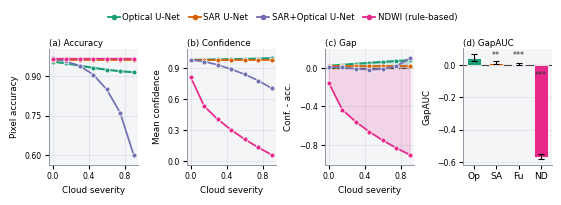

saved outputs/figures/fig1_panel_overview.pdf + .png


In [28]:
# --- Figure 1: PANEL OVERVIEW -- single row, 4 subpanels, one shared legend --
with style_ctx():
    fig, axes = plt.subplots(1, 4, figsize=(5.5, 2.0))
    plot_line_panel(axes[0], mean_acc, "Pixel accuracy", "(a) Accuracy", show_legend=False, tag="", compact=True)
    _safe_ylim(axes[0], mean_acc)
    plot_line_panel(axes[1], mean_conf, "Mean confidence", "(b) Confidence", show_legend=False, tag="", compact=True)
    _safe_ylim(axes[1], mean_conf)
    plot_gap_panel(axes[2], "(c) Gap", show_legend=False, tag="", compact=True)
    plot_gapauc_bars_panel(axes[3], "(d) GapAUC", tag="", compact=True)

    handles = [plt.Line2D([0], [0], color=PALETTE[i], lw=1.3, marker="o", ms=3)
               for i in range(len(MODEL_ORDER))]
    # NOTE: bbox_to_anchor y must stay <= ~0.99 -- anything above the figure's own 0..1
    # coordinate range gets clipped by savefig's default canvas (no bbox_inches="tight"
    # here, since that would silently change the figure's declared 5.5x2.0in size).
    top_reserved = 0.72 if DRY_RUN else 0.78
    fig.legend(handles, [MODEL_LABEL[n] for n in MODEL_ORDER], loc="upper center",
               bbox_to_anchor=(0.5, 0.995), ncol=4, fontsize=6.2, frameon=False,
               handlelength=1.4, handletextpad=0.3, columnspacing=1.0)
    if DRY_RUN:
        fig.text(0.5, 0.855, "DRY RUN — SYNTHETIC DATA, NOT REAL RESULTS", ha="center", va="top",
                  fontsize=5.4, color="#b33636")
    fig.subplots_adjust(left=0.075, right=0.99, top=top_reserved, bottom=0.20, wspace=0.55)
    save_figure(fig, "fig1_panel_overview")


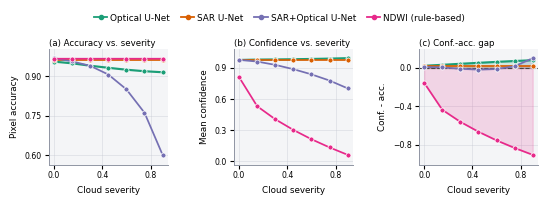

saved outputs/figures/fig2_panel_severity_curves.pdf + .png


In [29]:
# --- Figure 2: PANEL, single row, 3 subpanels -- accuracy / confidence / gap -
with style_ctx():
    fig, axes = plt.subplots(1, 3, figsize=(5.5, 2.0))
    plot_line_panel(axes[0], mean_acc, "Pixel accuracy", "(a) Accuracy vs. severity", show_legend=False, tag="", compact=True)
    _safe_ylim(axes[0], mean_acc)
    plot_line_panel(axes[1], mean_conf, "Mean confidence", "(b) Confidence vs. severity", show_legend=False, tag="", compact=True)
    _safe_ylim(axes[1], mean_conf)
    plot_gap_panel(axes[2], "(c) Conf.-acc. gap", show_legend=False, tag="", compact=True)

    handles = [plt.Line2D([0], [0], color=PALETTE[i], lw=1.3, marker="o", ms=3)
               for i in range(len(MODEL_ORDER))]
    top_reserved = 0.72 if DRY_RUN else 0.78
    fig.legend(handles, [MODEL_LABEL[n] for n in MODEL_ORDER], loc="upper center",
               bbox_to_anchor=(0.5, 0.995), ncol=4, fontsize=6.4, frameon=False,
               handlelength=1.5, handletextpad=0.35, columnspacing=1.2)
    if DRY_RUN:
        fig.text(0.5, 0.855, "DRY RUN — SYNTHETIC DATA, NOT REAL RESULTS", ha="center", va="top",
                  fontsize=5.4, color="#b33636")
    fig.subplots_adjust(left=0.08, right=0.97, top=top_reserved, bottom=0.20, wspace=0.55)
    save_figure(fig, "fig2_panel_severity_curves")


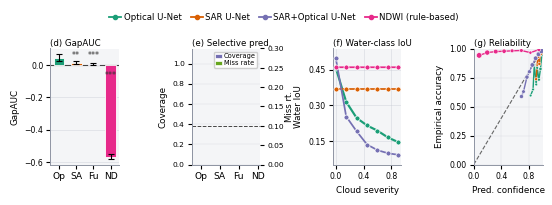

saved outputs/figures/fig3_panel_diagnostics.pdf + .png


In [32]:
# --- Figure 3: PANEL, single row, 4 subpanels -- GapAUC / selective pred. /
# water-IoU / reliability diagram. All four diagnostics that go beyond the headline
# accuracy/confidence curves, consolidated into one figure instead of four.
def _plot_selective_panel_compact(ax):
    xs = np.arange(len(MODEL_ORDER))
    covs = [sel_results[n]["coverage"] or 0.0 for n in MODEL_ORDER]
    risks = [sel_results[n]["test_miss_rate"] if sel_results[n]["test_miss_rate"] is not None else np.nan
             for n in MODEL_ORDER]
    ax2 = ax.twinx()
    b1 = ax.bar(xs - 0.18, covs, width=0.32, color=PALETTE[2], edgecolor="white", linewidth=0.5, zorder=2)
    b2 = ax2.bar(xs + 0.18, risks, width=0.32, color=PALETTE[4], edgecolor="white", linewidth=0.5, zorder=2)
    ax2.axhline(TARGET_MISS_RATE, color="#444444", lw=0.7, ls="--", zorder=1)
    short_labels = {"optical": "Op", "sar": "SA", "fusion": "Fu", "ndwi": "ND"}
    ax.set_xticks(xs)
    ax.set_xticklabels([short_labels[n] for n in MODEL_ORDER], fontsize=6.6)
    ax.set_ylabel("Coverage", fontsize=6.3); ax2.set_ylabel("Miss rt.", fontsize=6.1, labelpad=1)
    ax.set_title("(e) Selective pred.", fontsize=6.2, fontweight="normal", pad=2, loc="left")
    ax.set_ylim(0, 1.15)
    ax2.set_ylim(0, max(0.3, np.nanmax(risks) * 1.3 if len(risks) and np.isfinite(np.nanmax(risks)) else 0.3))
    ax.tick_params(axis="y", labelsize=5.4); ax2.tick_params(axis="y", labelsize=5.4)
    ax.tick_params(axis="x", labelsize=6.6)
    ax.grid(True, which="major", axis="y", lw=0.32, alpha=0.5, color="#c3c7cf", zorder=0)
    ax.set_axisbelow(True)
    ax.legend([b1, b2], ["Coverage", "Miss rate"], fontsize=4.8, frameon=True, edgecolor="#cccccc",
              facecolor="white", framealpha=0.95, loc="upper right", handlelength=1.0,
              handletextpad=0.25, borderpad=0.2, labelspacing=0.15)

def _plot_reliability_compact(ax):
    ax.plot([0, 1], [0, 1], color="#666666", lw=0.8, ls="--", zorder=1)
    for i, name in enumerate(MODEL_ORDER):
        xs, ys, ns = reliability_curve(test_conf[name], test_acc[name])
        sizes = 4 + 12 * (ns / max(ns.max(), 1))
        ax.plot(xs, ys, lw=1.0, color=PALETTE[i], zorder=2)
        ax.scatter(xs, ys, s=sizes, color=PALETTE[i], zorder=3, edgecolors="white", linewidths=0.4)
    ax.set_xlabel("Pred. confidence", fontsize=6.3)
    ax.set_ylabel("Empirical accuracy", fontsize=6.3)
    ax.set_title("(g) Reliability", fontsize=6.2, fontweight="normal", pad=2, loc="left")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.xaxis.set_major_locator(plt.MaxNLocator(3)); ax.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax.tick_params(labelsize=5.6)
    ax.grid(True, which="major", lw=0.32, alpha=0.5, color="#c3c7cf", zorder=0)
    ax.set_axisbelow(True)

def reliability_curve(conf_arr, acc_arr, n_bins=8):
    c = conf_arr.ravel(); a = acc_arr.ravel()
    edges = np.linspace(c.min(), c.max() + 1e-9, n_bins + 1)
    xs, ys, ns = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (c >= lo) & (c < hi)
        if mask.sum() == 0:
            continue
        xs.append(c[mask].mean()); ys.append(a[mask].mean()); ns.append(int(mask.sum()))
    return np.array(xs), np.array(ys), np.array(ns)

with style_ctx():
    fig, axes = plt.subplots(1, 4, figsize=(5.5, 2.0))
    plot_gapauc_bars_panel(axes[0], "(d) GapAUC", tag="", compact=True)
    _plot_selective_panel_compact(axes[1])
    plot_line_panel(axes[2], mean_iou, "Water IoU", "(f) Water-class IoU", show_legend=False, tag="", compact=True)
    _safe_ylim(axes[2], mean_iou)
    _plot_reliability_compact(axes[3])

    handles = [plt.Line2D([0], [0], color=PALETTE[i], lw=1.3, marker="o", ms=3)
               for i in range(len(MODEL_ORDER))]
    top_reserved = 0.72 if DRY_RUN else 0.78
    fig.legend(handles, [MODEL_LABEL[n] for n in MODEL_ORDER], loc="upper center",
               bbox_to_anchor=(0.5, 0.995), ncol=4, fontsize=6.2, frameon=False,
               handlelength=1.4, handletextpad=0.3, columnspacing=1.0)
    if DRY_RUN:
        fig.text(0.5, 0.855, "DRY RUN — SYNTHETIC DATA, NOT REAL RESULTS", ha="center", va="top",
                  fontsize=5.4, color="#b33636")
    fig.subplots_adjust(left=0.075, right=0.97, top=top_reserved, bottom=0.20, wspace=1.05)
    save_figure(fig, "fig3_panel_diagnostics")

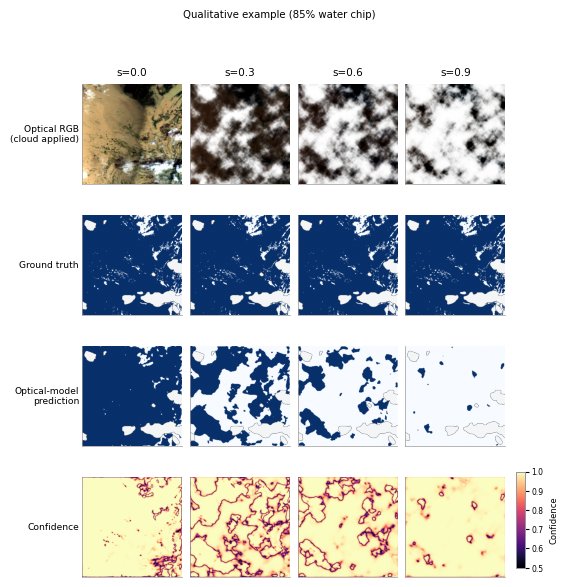

saved outputs/figures/figA1_qualitative_example.pdf + .png


In [42]:
appendix_sev = [0.0, 0.3, 0.6, 0.9]
water_fractions = {cid: (chips[cid][2] == 1).mean() for cid in test_ids}
example_cid = max(water_fractions, key=water_fractions.get)

def pct_stretch(rgb, lo=2, hi=98):
    out = np.empty_like(rgb)
    for c in range(3):
        band = rgb[..., c]
        p_lo, p_hi = np.percentile(band, [lo, hi])
        out[..., c] = np.clip((band - p_lo) / max(p_hi - p_lo, 1e-6), 0, 1)
    return out

s1_ex, s2_ex, lbl_ex = chips[example_cid]
models["optical"].eval()
with style_ctx():
    fig, axes = plt.subplots(4, len(appendix_sev), figsize=(5.5, 6.0))
    col_titles = [f"s={s:.1f}" for s in appendix_sev]
    row_titles = ["Optical RGB\n(cloud applied)", "Ground truth", "Optical-model\nprediction", "Confidence"]
    for j, sev in enumerate(appendix_sev):
        cloud = synth_cloud_mask(s2_ex.shape[-2], s2_ex.shape[-1], sev, seed=42)
        s2c = apply_cloud(s2_ex, cloud)
        rgb = pct_stretch(np.stack([s2c[3], s2c[2], s2c[1]], axis=-1))
        with torch.no_grad():
            x = make_input("optical", s1_ex, s2c)
            xt = torch.tensor(x[None]).float().to(DEVICE)
            p = torch.sigmoid(models["optical"](xt))[0, 0].cpu().numpy()
        pred = p > 0.5
        conf = np.maximum(p, 1 - p)
        valid_mask = (lbl_ex != -1)

        axes[0, j].imshow(rgb)
        axes[1, j].imshow(np.where(valid_mask, lbl_ex, np.nan), cmap="Blues", vmin=0, vmax=1)
        axes[2, j].imshow(np.where(valid_mask, pred, np.nan), cmap="Blues", vmin=0, vmax=1)
        im = axes[3, j].imshow(conf, cmap="magma", vmin=0.5, vmax=1.0)
        axes[0, j].set_title(col_titles[j], fontsize=7.5)
        for r in range(4):
            axes[r, j].set_xticks([]); axes[r, j].set_yticks([])
            for spine in axes[r, j].spines.values():
                spine.set_edgecolor("#999999"); spine.set_linewidth(0.5)
    for r in range(4):
        axes[r, 0].set_ylabel(row_titles[r], fontsize=6.6, rotation=0, ha="right", va="center", labelpad=2)
    cax = fig.add_axes([0.93, 0.06, 0.015, 0.16])
    fig.colorbar(im, cax=cax, label="Confidence")
    cax.tick_params(labelsize=5.5); cax.set_ylabel("Confidence", fontsize=6.0)
    fig.suptitle(f"Qualitative example ({water_fractions[example_cid]*100:.0f}% water chip)",
                 fontsize=7.3, y=0.99)
    if DRY_RUN:
        fig.text(0.5, 0.955, "DRY RUN -- SYNTHETIC DATA, NOT REAL RESULTS", ha="center", va="top",
                  fontsize=5.6, color="#b33636")
    fig.subplots_adjust(left=0.14, right=0.91, top=0.88, bottom=0.03, hspace=0.12, wspace=0.08)
    save_figure(fig, "figA1_qualitative_example")

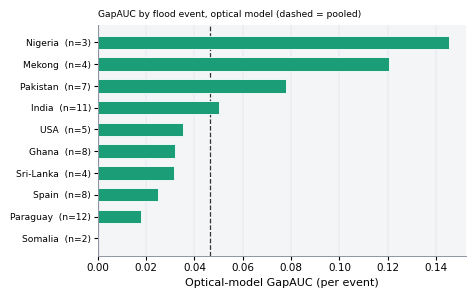

saved outputs/figures/figA2_per_event_generalization.pdf + .png


In [40]:
event_of = {cid: cid.split("_", 1)[0] for cid in test_ids}
events = sorted(set(event_of.values()))

event_gapauc, event_n = {}, {}
for ev in events:
    idx = [i for i, cid in enumerate(test_ids) if event_of[cid] == ev]
    if len(idx) == 0:
        continue
    g = test_conf["optical"][idx] - test_acc["optical"][idx]
    event_gapauc[ev] = gap_auc(SEVERITIES, g.mean(axis=0))
    event_n[ev] = len(idx)

order = sorted(event_gapauc, key=event_gapauc.get)
vals = [event_gapauc[ev] for ev in order]
ns = [event_n[ev] for ev in order]

with style_ctx():
    fig, ax = plt.subplots(figsize=(5.5, max(2.0, 0.24 * len(order) + 0.8)))
    ys = np.arange(len(order))
    colors = ["#1b9e77" if v > 0 else "#7570b3" for v in vals]
    ax.barh(ys, vals, color=colors, edgecolor="white", linewidth=0.6, height=0.62, zorder=2)
    ax.axvline(0, color="#444444", lw=0.8, zorder=1)
    ax.axvline(gap_results["optical"]["gapauc"], color="#333333", lw=0.9, ls="--", zorder=1)
    ax.set_yticks(ys)
    ax.set_yticklabels([f"{ev}  (n={n})" for ev, n in zip(order, ns)], fontsize=6.6)
    ax.set_xlabel("Optical-model GapAUC (per event)")
    ax.set_title("GapAUC by flood event, optical model (dashed = pooled)",
                 fontsize=6.6, loc="left")
    ax.grid(True, which="major", axis="x", lw=0.35, alpha=0.6, color="#c3c7cf", zorder=0)
    ax.set_axisbelow(True)
    top_margin = 0.80 if DRY_RUN else 0.88
    if DRY_RUN:
        fig.text(0.5, 0.965, "DRY RUN -- SYNTHETIC DATA, NOT REAL RESULTS", ha="center", va="top",
                 fontsize=5.6, color="#b33636")
    fig.subplots_adjust(left=0.30, right=0.97, top=top_margin, bottom=0.16)
    save_figure(fig, "figA2_per_event_generalization")

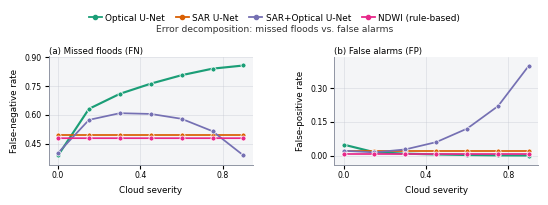

saved outputs/figures/figA3_fn_fp_breakdown.pdf + .png


In [41]:
def eval_fn_fp(ids, severities):
    keys = list(models) + ["ndwi"]
    fn_rate = {k: np.zeros((len(ids), len(severities))) for k in keys}
    fp_rate = {k: np.zeros((len(ids), len(severities))) for k in keys}
    for m in models.values():
        m.eval()
    with torch.no_grad():
        for ci, cid in enumerate(ids):
            s1, s2, lbl = chips[cid]
            valid = (lbl != -1)
            water = (lbl == 1) & valid
            notwater = (lbl == 0) & valid
            for si, sev in enumerate(severities):
                cloud = synth_cloud_mask(s2.shape[-2], s2.shape[-1], sev, seed=3000 + ci)
                s2c = apply_cloud(s2, cloud)
                for name in models:
                    x = make_input(name, s1, s2c) if name != "sar" else s1
                    xt = torch.tensor(x[None]).float().to(DEVICE)
                    p = torch.sigmoid(models[name](xt))[0, 0].cpu().numpy()
                    pred = p > 0.5
                    fn_rate[name][ci, si] = (water & ~pred).sum() / max(water.sum(), 1)
                    fp_rate[name][ci, si] = (notwater & pred).sum() / max(notwater.sum(), 1)
                pred_n, _ = ndwi_predict(s2c)
                pred_n = pred_n.astype(bool)
                fn_rate["ndwi"][ci, si] = (water & ~pred_n).sum() / max(water.sum(), 1)
                fp_rate["ndwi"][ci, si] = (notwater & pred_n).sum() / max(notwater.sum(), 1)
    return fn_rate, fp_rate

test_fn, test_fp = eval_fn_fp(test_ids, SEVERITIES)
mean_fn = {n: test_fn[n].mean(axis=0) for n in MODEL_ORDER}
mean_fp = {n: test_fp[n].mean(axis=0) for n in MODEL_ORDER}

with style_ctx():
    fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.0))
    plot_line_panel(axes[0], mean_fn, "False-negative rate", "(a) Missed floods (FN)", show_legend=False, tag="", compact=True)
    _safe_ylim(axes[0], mean_fn)
    plot_line_panel(axes[1], mean_fp, "False-positive rate", "(b) False alarms (FP)", show_legend=False, tag="", compact=True)
    _safe_ylim(axes[1], mean_fp)
    handles = [plt.Line2D([0], [0], color=PALETTE[i], lw=1.3, marker="o", ms=3) for i in range(len(MODEL_ORDER))]
    top_reserved = 0.68 if DRY_RUN else 0.74
    fig.legend(handles, [MODEL_LABEL[n] for n in MODEL_ORDER], loc="upper center",
               bbox_to_anchor=(0.5, 0.995), ncol=4, fontsize=6.4, frameon=False,
               handlelength=1.5, handletextpad=0.35, columnspacing=1.2)
    fig.text(0.5, 0.855 if DRY_RUN else 0.90,
              "Error decomposition: missed floods vs. false alarms",
              ha="center", va="top", fontsize=6.6, color="#b33636" if DRY_RUN else "#333333")
    fig.subplots_adjust(left=0.09, right=0.98, top=top_reserved, bottom=0.20, wspace=0.40)
    save_figure(fig, "figA3_fn_fp_breakdown")

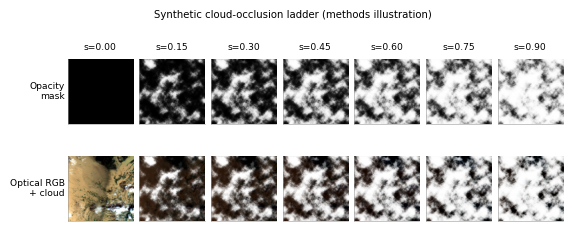

saved outputs/figures/figA4_cloud_ladder_illustration.pdf + .png


In [52]:
# ============================================================= Appendix Figure A4
# Methods transparency: what the synthetic cloud-occlusion ladder actually looks like.
# Top row = the raw opacity mask itself (independent of any chip); bottom row = that
# mask composited onto one real optical chip. Lets a reader (or reviewer) judge the
# realism of the degradation model directly, rather than taking "synthetic cloud" on faith.
# Self-contained: does not assume Figure A1 ran first.
def _pct_stretch(rgb, lo=2, hi=98):
    out = np.empty_like(rgb)
    for c in range(3):
        band = rgb[..., c]
        p_lo, p_hi = np.percentile(band, [lo, hi])
        out[..., c] = np.clip((band - p_lo) / max(p_hi - p_lo, 1e-6), 0, 1)
    return out

illus_cid = max(test_ids, key=lambda cid: (chips[cid][2] == 1).mean())
_, s2_illus, _ = chips[illus_cid]

with style_ctx():
    fig, axes = plt.subplots(2, len(SEVERITIES), figsize=(5.5, 2.3))
    for j, sev in enumerate(SEVERITIES):
        cloud = synth_cloud_mask(s2_illus.shape[-2], s2_illus.shape[-1], sev, seed=42)
        s2c = apply_cloud(s2_illus, cloud)
        rgb_c = _pct_stretch(np.stack([s2c[3], s2c[2], s2c[1]], axis=-1))
        axes[0, j].imshow(cloud, cmap="gray", vmin=0, vmax=1)
        axes[1, j].imshow(rgb_c)
        axes[0, j].set_title(f"s={sev:.2f}", fontsize=6.6)
        for r in range(2):
            axes[r, j].set_xticks([]); axes[r, j].set_yticks([])
            for spine in axes[r, j].spines.values():
                spine.set_edgecolor("#999999"); spine.set_linewidth(0.4)
    axes[0, 0].set_ylabel("Opacity\nmask", fontsize=6.6, rotation=0, ha="right", va="center", labelpad=2)
    axes[1, 0].set_ylabel("Optical RGB\n+ cloud", fontsize=6.6, rotation=0, ha="right", va="center", labelpad=2)
    fig.suptitle("Synthetic cloud-occlusion ladder (methods illustration)",
                 fontsize=7.3, y=0.99)
    if DRY_RUN:
        fig.text(0.5, 0.895, "DRY RUN -- SYNTHETIC DATA, NOT REAL RESULTS", ha="center", va="top",
                  fontsize=5.6, color="#b33636")
    fig.subplots_adjust(left=0.09, right=0.99, top=0.82, bottom=0.03, hspace=0.15, wspace=0.10)
    save_figure(fig, "figA4_cloud_ladder_illustration")

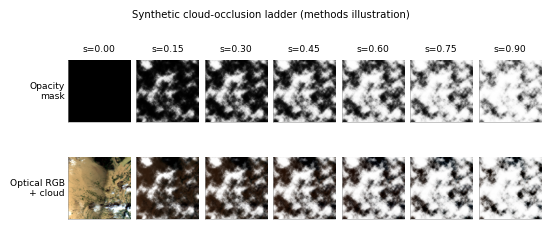

saved outputs/figures/figA4_cloud_ladder_illustration.pdf + .png


In [54]:
# ============================================================= Appendix Figure A4

# Methods transparency: what the synthetic cloud-occlusion ladder actually looks like.
# Top row = the raw opacity mask itself (independent of any chip); bottom row = that
# mask composited onto one real optical chip. Lets a reader (or reviewer) judge the
# realism of the degradation model directly, rather than taking "synthetic cloud" on faith.
# Self-contained: does not assume Figure A1 ran first.

def _pct_stretch(rgb, lo=2, hi=98):
    out = np.empty_like(rgb)
    for c in range(3):
        band = rgb[..., c]
        p_lo, p_hi = np.percentile(band, [lo, hi])
        out[..., c] = np.clip((band - p_lo) / max(p_hi - p_lo, 1e-6), 0, 1)
    return out


illus_cid = max(test_ids, key=lambda cid: (chips[cid][2] == 1).mean())
_, s2_illus, _ = chips[illus_cid]

with style_ctx():
    fig, axes = plt.subplots(2, len(SEVERITIES), figsize=(5.5, 2.3))

    for j, sev in enumerate(SEVERITIES):
        cloud = synth_cloud_mask(
            s2_illus.shape[-2],
            s2_illus.shape[-1],
            sev,
            seed=42
        )

        s2c = apply_cloud(s2_illus, cloud)
        rgb_c = _pct_stretch(
            np.stack([s2c[3], s2c[2], s2c[1]], axis=-1)
        )

        axes[0, j].imshow(cloud, cmap="gray", vmin=0, vmax=1)
        axes[1, j].imshow(rgb_c)

        axes[0, j].set_title(f"s={sev:.2f}", fontsize=6.6)

        for r in range(2):
            axes[r, j].set_xticks([])
            axes[r, j].set_yticks([])

            for spine in axes[r, j].spines.values():
                spine.set_edgecolor("#999999")
                spine.set_linewidth(0.4)

    axes[0, 0].set_ylabel(
        "Opacity\nmask",
        fontsize=6.6,
        rotation=0,
        ha="right",
        va="center",
        labelpad=2
    )

    axes[1, 0].set_ylabel(
        "Optical RGB\n+ cloud",
        fontsize=6.6,
        rotation=0,
        ha="right",
        va="center",
        labelpad=2
    )

    fig.suptitle(
        "Synthetic cloud-occlusion ladder (methods illustration)",
        fontsize=7.3,
        y=0.99
    )

    if DRY_RUN:
        fig.text(
            0.5,
            0.895,
            "DRY RUN -- SYNTHETIC DATA, NOT REAL RESULTS",
            ha="center",
            va="top",
            fontsize=5.6,
            color="#b33636"
        )

    # Only fix: give the left-side labels a little more room.
    fig.subplots_adjust(
        left=0.13,
        right=0.99,
        top=0.82,
        bottom=0.03,
        hspace=0.15,
        wspace=0.10
    )

    save_figure(fig, "figA4_cloud_ladder_illustration")

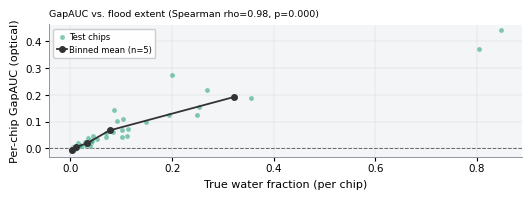

saved outputs/figures/figA5_gapauc_vs_water_fraction.pdf + .png


In [55]:
# ============================================================= Appendix Figure A5
# Does the blind-confidence effect hit small/subtle floods harder than large, obvious
# ones? Per test chip: x = true water fraction, y = that chip's own GapAUC (optical
# model). Small floods are arguably the higher-stakes case operationally -- they're
# the ones most likely to be missed entirely.
water_frac_arr = np.array([(chips[cid][2] == 1).mean() for cid in test_ids])
per_chip_gap_optical = test_conf["optical"] - test_acc["optical"]  # (n_chips, n_sev)
per_chip_gapauc = np.array([gap_auc(SEVERITIES, per_chip_gap_optical[i]) for i in range(len(test_ids))])

valid_mask = water_frac_arr > 0  # chips with zero water can't inform this question
wf, gv = water_frac_arr[valid_mask], per_chip_gapauc[valid_mask]
rho, rho_p = sstats.spearmanr(wf, gv) if len(wf) > 2 else (np.nan, np.nan)

n_bins = min(5, max(2, len(wf) // 6))
if len(wf) >= 2 * n_bins:
    edges = np.quantile(wf, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    bin_x, bin_y = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (wf >= lo) & (wf < hi)
        if m.sum() > 0:
            bin_x.append(wf[m].mean()); bin_y.append(gv[m].mean())
else:
    bin_x, bin_y = [], []

with style_ctx():
    fig, ax = plt.subplots(figsize=(5.5, 2.0))
    ax.scatter(wf, gv, s=14, color=PALETTE[0], alpha=0.55, edgecolors="white",
               linewidths=0.4, zorder=2, label="Test chips")
    if bin_x:
        ax.plot(bin_x, bin_y, color="#333333", lw=1.3, marker="o", ms=4, zorder=3,
                label=f"Binned mean (n={n_bins})")
    ax.axhline(0, color="#666666", lw=0.7, ls="--", zorder=1)
    ax.set_xlabel("True water fraction (per chip)")
    ax.set_ylabel("Per-chip GapAUC (optical)")
    rho_str = f"{rho:.2f}" if np.isfinite(rho) else "n/a"
    p_str = f"{rho_p:.3f}" if np.isfinite(rho_p) else "n/a"
    ax.set_title(f"GapAUC vs. flood extent (Spearman rho={rho_str}, p={p_str})",
                 fontsize=6.8, loc="left")
    ax.grid(True, which="major", lw=0.35, alpha=0.6, color="#c3c7cf", zorder=0)
    ax.set_axisbelow(True)
    ax.legend(fontsize=6.0, frameon=True, edgecolor="#cccccc", facecolor="white",
              framealpha=0.95, loc="best", handlelength=1.2, handletextpad=0.3)
    top_margin = 0.80 if DRY_RUN else 0.86
    if DRY_RUN:
        fig.text(0.5, 0.965, "DRY RUN -- SYNTHETIC DATA, NOT REAL RESULTS", ha="center", va="top",
                 fontsize=5.6, color="#b33636")
    fig.subplots_adjust(left=0.11, right=0.97, top=top_margin, bottom=0.20)
    save_figure(fig, "figA5_gapauc_vs_water_fraction")

## Tables

In [56]:
# --- Table 1: GapAUC + CI + significance vs. optical -------------------------
rows1 = []
for n in MODEL_ORDER:
    ci_str = f"[{gap_results[n]['ci_lo']:+.3f}, {gap_results[n]['ci_hi']:+.3f}]"
    p_str = "--" if n == "optical" else f"{pvals.get(('optical', n), float('nan')):.4f}"
    rows1.append([MODEL_LABEL[n], f"{gap_results[n]['gapauc']:+.3f}", ci_str, p_str])

def write_latex_table(rows, colnames, caption, label, path):
    lines = [r"\begin{table}[t]", r"\centering", r"\caption{" + caption + "}",
             r"\label{" + label + "}", r"\begin{tabular}{l" + "c" * (len(colnames) - 1) + "}",
             r"\toprule", " & ".join(colnames) + r" \\", r"\midrule"]
    for row in rows:
        lines.append(" & ".join(str(x) for x in row) + r" \\")
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
    with open(path, "w") as f:
        f.write("\n".join(lines))

tag_caption = " (DRY RUN -- synthetic data, not real results)" if DRY_RUN else ""
write_latex_table(
    rows1, ["Model", "GapAUC", "95\\% CI", "$p$ vs.\\ Optical (Bonf.)"],
    caption=f"Confidence--accuracy GapAUC by model under the synthetic cloud-severity ladder{tag_caption}.",
    label="tab:gapauc", path=os.path.join(TAB_DIR, f"table1_gapauc{TAG}.tex"))
pd.DataFrame(rows1, columns=["model", "gapauc", "ci95", "p_vs_optical"]).to_csv(
    os.path.join(TAB_DIR, f"table1_gapauc{TAG}.csv"), index=False)
print(pd.DataFrame(rows1, columns=["model", "gapauc", "ci95", "p_vs_optical"]))


               model  gapauc              ci95 p_vs_optical
0      Optical U-Net  +0.047  [+0.027, +0.070]           --
1          SAR U-Net  +0.014  [+0.006, +0.025]       0.0056
2  SAR+Optical U-Net  +0.006  [-0.001, +0.013]       0.0001
3  NDWI (rule-based)  -0.566  [-0.583, -0.551]       0.0000


In [57]:
# --- Table 2: pixel accuracy AT the representative severities ----------------
rep_severities = [SEVERITIES[0], SEVERITIES[len(SEVERITIES)//2], SEVERITIES[-1]]
rows2 = []
for n in MODEL_ORDER:
    accs_at = [test_acc[n][:, SEVERITIES.index(s)].mean() for s in rep_severities]
    rows2.append([MODEL_LABEL[n]] + [f"{a:.3f}" for a in accs_at])

write_latex_table(
    rows2, ["Model"] + [f"Acc @ s={s:.2f}" for s in rep_severities],
    caption=f"Pixel accuracy at representative cloud severities{tag_caption}.",
    label="tab:acc_by_severity", path=os.path.join(TAB_DIR, f"table2_accuracy{TAG}.tex"))
pd.DataFrame(rows2, columns=["model"] + [f"acc_s{s}" for s in rep_severities]).to_csv(
    os.path.join(TAB_DIR, f"table2_accuracy{TAG}.csv"), index=False)
print(pd.DataFrame(rows2, columns=["model"] + [f"acc_s{s}" for s in rep_severities]))


               model acc_s0.0 acc_s0.45 acc_s0.9
0      Optical U-Net    0.955     0.931    0.914
1          SAR U-Net    0.959     0.959    0.959
2  SAR+Optical U-Net    0.968     0.906    0.602
3  NDWI (rule-based)    0.966     0.966    0.966


In [58]:
# --- Table 3: WATER-CLASS IoU/F1 at representative severities ----------------
# Raw pixel accuracy on flood chips is class-imbalance-prone (mostly non-water pixels
# even in a flooded chip), so a model can post high "accuracy" while its actual water
# detection has collapsed. This table reports the metric that actually isolates that.
rows3 = []
for n in MODEL_ORDER:
    ious_at = [test_iou[n][:, SEVERITIES.index(s)].mean() for s in rep_severities]
    f1s_at  = [test_f1[n][:, SEVERITIES.index(s)].mean() for s in rep_severities]
    row = [MODEL_LABEL[n]]
    for iou_v, f1_v in zip(ious_at, f1s_at):
        row.append(f"{iou_v:.3f} / {f1_v:.3f}")
    rows3.append(row)

write_latex_table(
    rows3, ["Model"] + [f"IoU/F1 @ s={s:.2f}" for s in rep_severities],
    caption=f"Water-class IoU / F1 (not overall accuracy) at representative cloud "
            f"severities{tag_caption}.",
    label="tab:iou_f1_by_severity", path=os.path.join(TAB_DIR, f"table3_water_iou_f1{TAG}.tex"))
pd.DataFrame(rows3, columns=["model"] + [f"iou_f1_s{s}" for s in rep_severities]).to_csv(
    os.path.join(TAB_DIR, f"table3_water_iou_f1{TAG}.csv"), index=False)
print(pd.DataFrame(rows3, columns=["model"] + [f"iou_f1_s{s}" for s in rep_severities]))


               model    iou_f1_s0.0   iou_f1_s0.45    iou_f1_s0.9
0      Optical U-Net  0.457 / 0.548  0.216 / 0.265  0.146 / 0.151
1          SAR U-Net  0.369 / 0.453  0.369 / 0.453  0.369 / 0.453
2  SAR+Optical U-Net  0.498 / 0.597  0.136 / 0.198  0.093 / 0.140
3  NDWI (rule-based)  0.460 / 0.538  0.460 / 0.538  0.460 / 0.538


## Output packaging

In [59]:
# --- Results summary, zip, download (MANDATORY final cell) -------------------
summary = {
    "dry_run": DRY_RUN,
    "n_train": len(train_ids), "n_val": len(val_ids), "n_test": len(test_ids),
    "severities": SEVERITIES,
    "gapauc": gap_results,
    "pairwise_p_values": {f"{a}_vs_{b}": p for (a, b), p in pvals.items()},
    "mean_water_iou_by_model": {n: mean_iou[n].tolist() for n in MODEL_ORDER},
    "selective_prediction": sel_results,
    "config": {"IMG_SIZE": IMG_SIZE, "EPOCHS": EPOCHS, "BATCH_SIZE": BATCH_SIZE, "LR": LR,
               "TARGET_MISS_RATE": TARGET_MISS_RATE, "MAX_CHIPS": MAX_CHIPS, "SEED": SEED},
}
with open(os.path.join(LOG_DIR, f"results_summary{TAG}.json"), "w") as f:
    json.dump(summary, f, indent=2, default=float)

print("=" * 70)
print("RESULTS SUMMARY" + ("  [DRY RUN — SYNTHETIC DATA, NOT REAL RESULTS]" if DRY_RUN else ""))
print("=" * 70)
for n in MODEL_ORDER:
    print(f"  {MODEL_LABEL[n]:20s} GapAUC={gap_results[n]['gapauc']:+.3f}  "
          f"95%CI=[{gap_results[n]['ci_lo']:+.3f},{gap_results[n]['ci_hi']:+.3f}]  "
          f"water-IoU(s=0->s={SEVERITIES[-1]:.2f})={mean_iou[n][0]:.3f}->{mean_iou[n][-1]:.3f}")
print("-" * 70)
print("Generated files:")
all_files = []
for root, _, files in os.walk(OUT_DIR):
    for fn in files:
        p = os.path.join(root, fn)
        all_files.append(p)
        print(" ", p)

zip_path = "outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in all_files:
        zf.write(p, arcname=os.path.relpath(p, "."))
print(f"\nZIP created: {zip_path} ({os.path.getsize(zip_path)/1024:.1f} KB), "
      f"{len(all_files)} files packaged.")

try:
    from google.colab import files as colab_files
    colab_files.download(zip_path)
    print("Download triggered via Colab.")
except ImportError:
    print(f"Not running in Colab — zip is saved locally at: {os.path.abspath(zip_path)}")


RESULTS SUMMARY
  Optical U-Net        GapAUC=+0.047  95%CI=[+0.027,+0.070]  water-IoU(s=0->s=0.90)=0.457->0.146
  SAR U-Net            GapAUC=+0.014  95%CI=[+0.006,+0.025]  water-IoU(s=0->s=0.90)=0.369->0.369
  SAR+Optical U-Net    GapAUC=+0.006  95%CI=[-0.001,+0.013]  water-IoU(s=0->s=0.90)=0.498->0.093
  NDWI (rule-based)    GapAUC=-0.566  95%CI=[-0.583,-0.551]  water-IoU(s=0->s=0.90)=0.460->0.460
----------------------------------------------------------------------
Generated files:
  outputs/logs/results_summary.json
  outputs/tables/table1_gapauc.tex
  outputs/tables/table1_gapauc.csv
  outputs/tables/table3_water_iou_f1.tex
  outputs/tables/table2_accuracy.csv
  outputs/tables/table3_water_iou_f1.csv
  outputs/tables/table2_accuracy.tex
  outputs/figures/figA4_cloud_ladder_illustration.png
  outputs/figures/figA1_qualitative_example.pdf
  outputs/figures/fig1_panel_overview.png
  outputs/figures/figA1_qualitative_example.png
  outputs/figures/fig3_panel_diagnostics.pdf
  outputs

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered via Colab.
